# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 - Student 1: Celine MIchael - 327946109

 - Student 2: Nell Khoury - 327851754

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [ ]:
## Standard libraries
import math
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

plt.set_cmap('cividis')
%matplotlib inline
%config InlineBackend.figure_formats = ['svg', 'pdf']

## Progress bar
## PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

# Torchvision
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm.notebook import tqdm

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# Continuous representation:
# Cast to float, add uniform noise in [0,1], scale from [0,256] to [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255.0 + torch.rand_like(x)) / 256.0)
])

train_dataset = MNIST(root=DATASET_PATH, train=True,  transform=transform, download=True)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])
test_set  = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True,  drop_last=True,
                               pin_memory=torch.cuda.is_available(), num_workers=0)
val_loader   = data.DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=0)
test_loader  = data.DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)

print('Train size:',      len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:',       len(test_loader.dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 537kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


Train size: 50000
Validation size: 10000
Test size: 10000


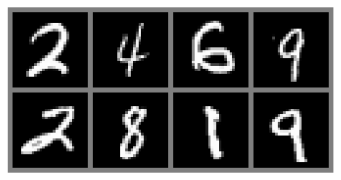

In [ ]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = math.ceil(num_imgs / nrow)
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=0.5)
    imgs = imgs.clamp(0, 1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5 * nrow, 1.5 * ncol))
    plt.imshow(np.transpose(np_imgs, (1, 2, 0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

## Question 1: VAE Implementation and Training

We implement a Variational Autoencoder consisting of:
- **Encoder**: convolutional layers (stride=2 to downsample) -> FC layers -> outputs μ and log σ² for the posterior q(z|x)
- **Decoder**: FC layers -> transposed convolutions -> sigmoid output as the mean of p(x|z)
- **Prior**: standard isotropic Gaussian p(z) = N(0, I)

Training minimises the **negative ELBO** = Reconstruction loss + KL divergence, using the reparameterisation trick for differentiable sampling.

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.logs = defaultdict(list)

        # ENCODER
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28→14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14→7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 7→7
            nn.ReLU(),
            nn.Flatten()
        )
        self.encoder_fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1024), nn.ReLU(),
            nn.Linear(1024, 512),         nn.ReLU()
        )
        # Posterior parameters: mean and log-variance
        self.fc_mu     = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        # DECODER
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, 128 * 7 * 7), nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7→14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 14→28
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16,  1, kernel_size=3, padding=1),
            nn.Sigmoid()  # output in [0,1] = mean of p(x|z)
        )

    def encode(self, x):
        """Returns (mu, log_var) of posterior q(z|x)."""
        h = self.encoder_conv(x)
        h = self.encoder_fc(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        """Returns mean of p(x|z) in [0,1]."""
        h = self.decoder_fc(z)
        h = h.view(-1, 128, 7, 7)
        return self.decoder_conv(h)

    def calc_elbo(self, x):
        """Computes the negative ELBO = rec_loss + KLD.

        Reconstruction loss: -log p(x|z) with fixed var=0.01
          = 1/(2*0.01) * ||x_hat - x||^2  (summed over pixels, averaged over batch)

        KL divergence: KL(q(z|x) || p(z)) with p(z)=N(0,I)
          = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
        """
        mu, log_var = self.encode(x)

        # Reparameterisation trick: z = mu + eps*std, eps ~ N(0,I)
        std = torch.exp(0.5 * log_var)
        q = torch.distributions.Normal(mu, std)
        z = q.rsample()

        x_hat = self.decode(z)

        # Reconstruction loss with constant decoder variance sigma^2 = 0.1^2 = 0.01
        var      = 0.01
        x_flat   = x.view(x.size(0), -1)
        xh_flat  = x_hat.view(x_hat.size(0), -1)
        rec_loss = (1.0 / (2.0 * var)) * ((xh_flat - x_flat) ** 2).sum(dim=1).mean()

        # Closed-form KL between diagonal Gaussian and N(0,I)
        KLD = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).sum(dim=1).mean()

        neg_elbo = rec_loss + KLD
        return neg_elbo, rec_loss, KLD

    @torch.no_grad()
    def sample(self, num_samples):
        """Sample z from the prior p(z)=N(0,I) and decode to get image means."""
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        return self.decode(z)

    def log(self, key, value):
        self.logs[key].append(value)

    def training_step(self, batch):
        neg_elbo, rec_loss, KLD = self.calc_elbo(batch)
        self.log('train_elbo',  neg_elbo.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD',   KLD.item())
        return neg_elbo

    @torch.no_grad()
    def validation_step(self, loader):
        results = [self.calc_elbo(imgs.to(device)) for imgs, _ in tqdm(loader, leave=False)]
        elbos, recs, klds = zip(*results, strict=False)
        self.log('val_elbo',  torch.tensor([l.item() for l in elbos]).mean().item())
        self.log('val_recon', torch.tensor([l.item() for l in recs]).mean().item())
        self.log('val_KLD',   torch.tensor([l.item() for l in klds]).mean().item())
        return self.logs['val_elbo'][-1]

    @torch.no_grad()
    def test_step(self, loader):
        results = [self.calc_elbo(imgs.to(device)) for imgs, _ in tqdm(loader, leave=False)]
        elbos, recs, klds = zip(*results, strict=False)
        self.log('test_elbo',  torch.tensor([l.item() for l in elbos]).mean().item())
        self.log('test_recon', torch.tensor([l.item() for l in recs]).mean().item())
        self.log('test_KLD',   torch.tensor([l.item() for l in klds]).mean().item())
        return self.logs['test_elbo'][-1]

### Model Architecture

**Encoder:** 3 Conv layers (first two with stride=2 to halve spatial dims, third with stride=1 for extra features) -> Flatten -> 2 FC layers -> separate linear heads for μ and log σ².

**Decoder:** 3 FC layers -> reshape to (128, 7, 7) -> 2 ConvTranspose layers (stride=2 to upsample back to 28×28) -> 2 Conv refinement layers -> Sigmoid.

**Latent dim = 32** gave the best balance between expressiveness and regularisation.

## Model Training

In [ ]:
model = VAE(latent_dim=32).to(device)
print(f'Num params: {sum(p.numel() for p in model.parameters()):,}')

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.99)
epochs = 25

Num params: 14,228,129


In [ ]:
train_elbos, train_recons, train_klds = [], [], []

for epoch in range(epochs):
    model.train()
    batch_elbos, batch_recons, batch_klds = [], [], []

    for imgs, _ in tqdm(train_loader, leave=False):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        neg_elbo, rec_loss, KLD = model.calc_elbo(imgs)
        neg_elbo.backward()
        optimizer.step()
        # log per batch
        model.log('train_elbo',  neg_elbo.item())
        model.log('train_recon', rec_loss.item())
        model.log('train_KLD',   KLD.item())
        batch_elbos.append(neg_elbo.item())
        batch_recons.append(rec_loss.item())
        batch_klds.append(KLD.item())

    scheduler.step()
    val_loss = model.validation_step(val_loader)

    # Epoch averages
    ep_elbo  = np.mean(batch_elbos)
    ep_recon = np.mean(batch_recons)
    ep_kld   = np.mean(batch_klds)
    train_elbos.append(ep_elbo)
    train_recons.append(ep_recon)
    train_klds.append(ep_kld)

    print(f'Epoch {epoch+1:02d}/{epochs} | '
          f'Train ELBO: {ep_elbo:.2f} | '
          f'Recon: {ep_recon:.2f} | '
          f'KLD: {ep_kld:.2f} | '
          f'Val ELBO: {val_loss:.2f}')

torch.save(model.state_dict(), 'vae_model.pth')
print('Model saved.')

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/25 | Train ELBO: 2509.59 | Recon: 2491.03 | KLD: 18.57 | Val ELBO: 1690.30


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/25 | Train ELBO: 286.44 | Recon: 240.46 | KLD: 45.98 | Val ELBO: 326.21


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/25 | Train ELBO: 282.53 | Recon: 236.59 | KLD: 45.94 | Val ELBO: 326.41
Model saved.


In [ ]:
model.eval()
test_elbo = model.test_step(test_loader)
print(f'Final Test Set Negative ELBO: {test_elbo:.4f}')

  0%|          | 0/79 [00:00<?, ?it/s]

Final Test Set Negative ELBO: 328.0659


In [ ]:
model.eval()
test_elbo = model.test_step(test_loader)
print(f"Final Test Set ELBO: {test_elbo:.4f}")


  0%|          | 0/79 [00:00<?, ?it/s]

Final Test Set ELBO: 327.9293


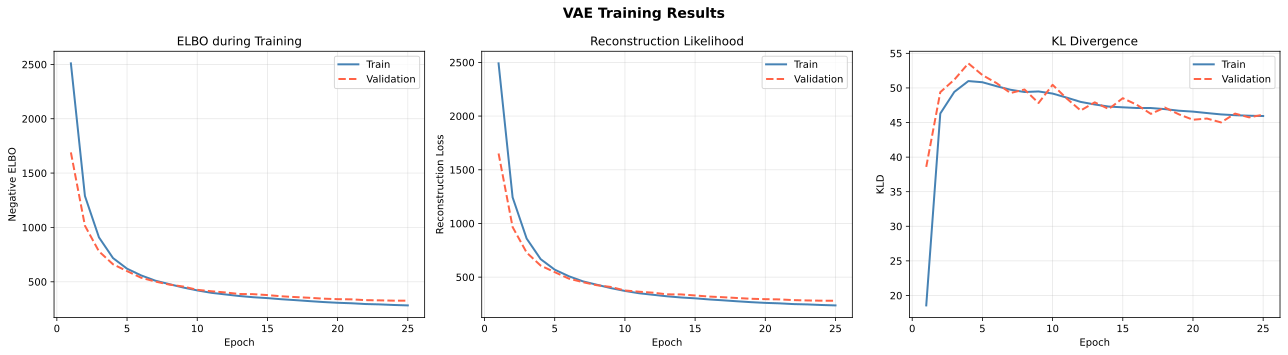

In [ ]:
val_elbos  = model.logs['val_elbo']
val_recons = model.logs['val_recon']
val_klds   = model.logs['val_KLD']
ep = range(1, len(train_elbos) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VAE Training Results', fontsize=14, fontweight='bold')

# Plot 1: ELBO (train + val)
axes[0].plot(ep, train_elbos, color='steelblue', linewidth=2, linestyle='-', label='Train')
axes[0].plot(ep, val_elbos,   color='tomato',     linewidth=2, linestyle='--', label='Validation')
axes[0].set_title('ELBO during Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative ELBO')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Reconstruction Loss
axes[1].plot(ep, train_recons, color='steelblue', linewidth=2, linestyle='-',  label='Train')
axes[1].plot(ep, val_recons,   color='tomato',         linewidth=2, linestyle='--', label='Validation')
axes[1].set_title('Reconstruction Likelihood')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: KL Divergence
axes[2].plot(ep, train_klds, color='steelblue', linewidth=2, linestyle='-',  label='Train')
axes[2].plot(ep, val_klds,   color='tomato',    linewidth=2, linestyle='--', label='Validation')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KLD')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Generated samples from prior p(z) = N(0,I):


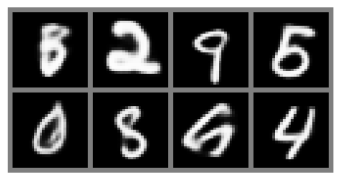

In [ ]:
samples = model.sample(num_samples=8)
print('Generated samples from prior p(z) = N(0,I):')
show_imgs(samples)

## Question 2 - Latent Space Traversals

For each of 3 pairs of digits, we compare two types of interpolation:
- **Latent space**: encode both images to get z1 and z2, interpolate 10 steps between them, decode each step
- **Pixel space**: interpolate directly between the raw pixel values

The latent interpolation should produce smooth, realistic transitions because the VAE learned a structured latent space. Pixel interpolation just blends pixels - no understanding of the data.

In [ ]:
# Find the first example of each digit we need from the test set
pairs_digits = [(2, 3), (0, 6), (1, 8)]
needed = set(d for pair in pairs_digits for d in pair)

first_idx = {}
for idx, (img, label) in enumerate(test_set):
    label = int(label)
    if label in needed and label not in first_idx:
        first_idx[label] = idx
    if len(first_idx) == len(needed):
        break

print('Found indices:', first_idx)

Found indices: {2: 1, 1: 2, 0: 3, 6: 11, 3: 18, 8: 61}


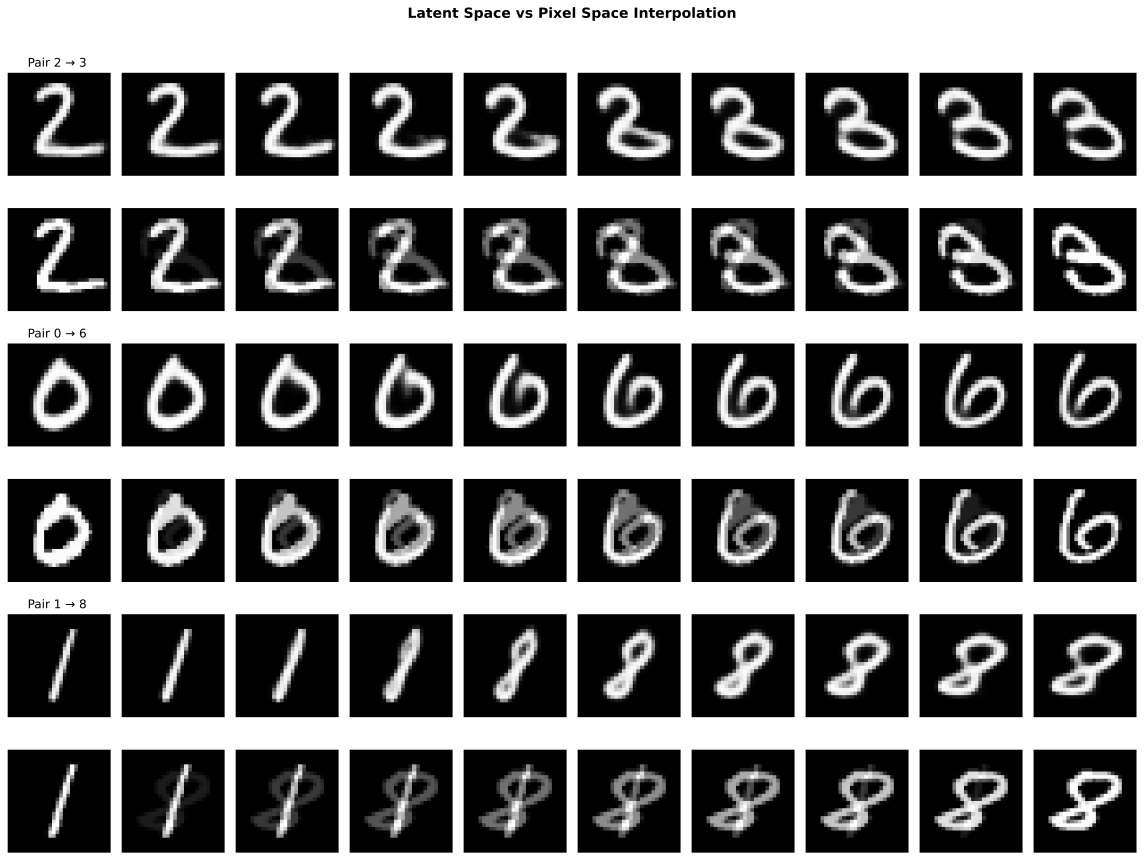

In [ ]:
model.eval()
N_STEPS = 10
n_pairs = len(pairs_digits)

# Extra rows for text labels between pairs
fig, axes = plt.subplots(n_pairs * 2, N_STEPS, figsize=(N_STEPS * 1.6, n_pairs * 4))
fig.suptitle('Latent Space vs Pixel Space Interpolation', fontsize=14, fontweight='bold', y=1.01)

for row_pair, (d1, d2) in enumerate(pairs_digits):
    img1 = test_set[first_idx[d1]][0].unsqueeze(0).to(device)
    img2 = test_set[first_idx[d2]][0].unsqueeze(0).to(device)

    with torch.no_grad():
        mu1, log_var1 = model.encode(img1)
        z1 = mu1 + torch.exp(0.5 * log_var1) * torch.randn_like(mu1)
        mu2, log_var2 = model.encode(img2)
        z2 = mu2 + torch.exp(0.5 * log_var2) * torch.randn_like(mu2)

    lat_row = row_pair * 2
    pix_row = row_pair * 2 + 1

    for i, t in enumerate(np.linspace(0, 1, N_STEPS)):
        z_t = (1 - t) * z1 + t * z2
        with torch.no_grad():
            recon = model.decode(z_t).squeeze().cpu().numpy()
        pix_t = ((1 - t) * img1 + t * img2).squeeze().cpu().numpy()

        axes[lat_row, i].imshow(recon, cmap='gray', vmin=0, vmax=1)
        axes[lat_row, i].axis('off')
        axes[pix_row, i].imshow(pix_t, cmap='gray', vmin=0, vmax=1)
        axes[pix_row, i].axis('off')

    # Clear left label using set_ylabel with big font
    axes[lat_row, 0].set_ylabel(f'Digit {d1}→{d2}\nLatent', fontsize=11,
                                 color='steelblue', fontweight='bold', labelpad=10)
    axes[pix_row, 0].set_ylabel(f'Digit {d1}→{d2}\nPixel',  fontsize=11,
                                 color='coral',     fontweight='bold', labelpad=10)
    axes[lat_row, 0].yaxis.set_tick_params(labelleft=True)
    axes[pix_row, 0].yaxis.set_tick_params(labelleft=True)

    # Title above the latent row
    axes[lat_row, 0].set_title(f'Pair {d1} → {d2} ',
                                         fontsize=12, color='black', pad=6)

plt.tight_layout(h_pad=0.5)
plt.show()

The latent space interpolation (odd rows) produces smooth, realistic transitions between digits - the model generates valid-looking digits at every step because the VAE learned a structured continuous latent space where nearby points decode to similar images.

The pixel space interpolation (even rows) just blends the raw pixel values, which creates a ghosting/overlap effect in the middle steps — you can see both digits superimposed on each other. This is not a meaningful transition, just a visual average.

This confirms that the VAE's latent space is semantically organised: moving in a straight line between two latent codes produces a smooth path through the space of digits.

## Question 3 - Image Inpainting

Given only the top half of an MNIST image, we predict the missing bottom half using three different methods. We test all methods on the same 6 images.

In [ ]:
# Mask: 1 = observed (top half), 0 = missing (bottom half)
mask = torch.zeros(1, 1, 28, 28, device=device)
mask[:, :, :14, :] = 1.0

# Pick 6 test images
def get_test_images(dataset, digits):
    imgs, labels = [], []
    seen = set()
    for img, lbl in dataset:
        lbl = int(lbl)
        if lbl not in seen and lbl in digits:
            imgs.append(img)
            labels.append(lbl)
            seen.add(lbl)
        if len(seen) == len(digits):
            break
    return torch.stack(imgs).to(device), labels

test_imgs, test_labels = get_test_images(test_set, digits={0,1,3,4,5,8})

observed_display = mask * test_imgs + (1 - mask) * 0.3

In [ ]:
def plot_inpainting(observed, ground_truth, results, title):
    n = len(ground_truth)
    fig, axes = plt.subplots(n, 3, figsize=(6, n * 2))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    axes[0, 0].set_title('Observed half', fontsize=9)
    axes[0, 1].set_title('Ground truth',  fontsize=9)
    axes[0, 2].set_title('Result',         fontsize=9)

    for i in range(n):
        axes[i, 0].imshow(observed[i].squeeze().cpu().numpy(),      cmap='gray', vmin=0, vmax=1)
        axes[i, 1].imshow(ground_truth[i].squeeze().cpu().numpy(),  cmap='gray', vmin=0, vmax=1)
        axes[i, 2].imshow(results[i].squeeze().cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)
        for j in range(3):
            axes[i, j].axis('off')
        axes[i, 0].set_ylabel(f'digit {test_labels[i]}', fontsize=9)

    plt.tight_layout()
    plt.show()

**Method (a) - Iterative Encode-Decode with Clamping**

We initialise the missing pixels with random noise, then repeatedly:
1. Encode the full image to get z
2. Decode z to get a reconstruction
3. Clamp the top half back to the real observed pixels

After 30 iterations the bottom half converges to something consistent with the top.

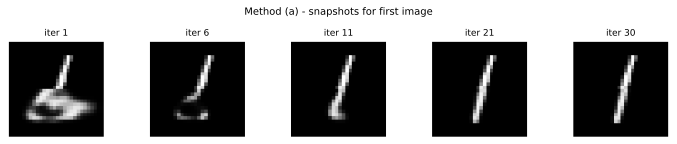

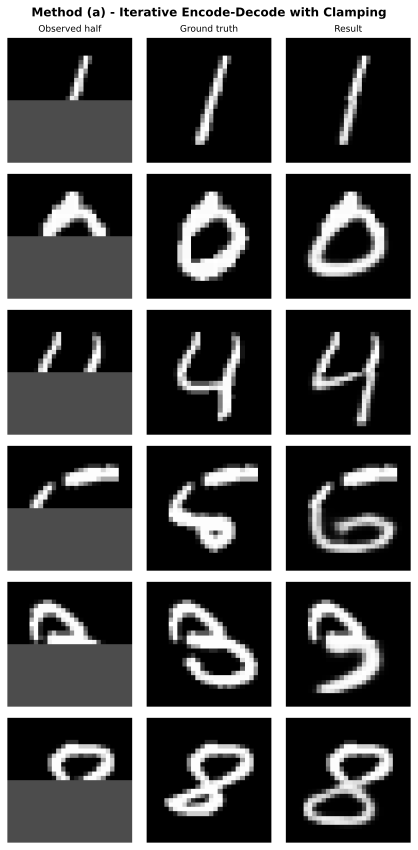

In [ ]:
model.eval()
N_ITER = 30
results_a = []

for i in range(len(test_imgs)):
    x_obs = test_imgs[i:i+1]  # shape (1,1,28,28)

    # Start with random noise in the missing half
    x_t = mask * x_obs + (1 - mask) * torch.rand_like(x_obs)

    for _ in range(N_ITER):
        with torch.no_grad():
            mu, log_var = model.encode(x_t)
            # Use posterior mean for stability (no sampling noise)
            x_hat = model.decode(mu)
        # Clamp: keep real top half, update bottom half with decoder output
        x_t = mask * x_obs + (1 - mask) * x_hat
    # Show snapshots for first image only
    if i == 0:
        snapshot_iters = [0, 5, 10, 20, 29]
        snapshots = []
        x_t = mask * x_obs + (1 - mask) * torch.rand_like(x_obs)
        for it in range(N_ITER):
            with torch.no_grad():
                mu, log_var = model.encode(x_t)
                std = torch.exp(0.5 * log_var)
                q = torch.distributions.Normal(mu, std)
                z = q.rsample()
                x_hat = model.decode(z)
            x_t = mask * x_obs + (1 - mask) * x_hat
            if it in snapshot_iters:
                snapshots.append((it+1, x_t.squeeze().cpu().numpy()))

        fig, axes = plt.subplots(1, len(snapshots), figsize=(len(snapshots)*2, 2))
        for ax, (it, img) in zip(axes, snapshots, strict=False):
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'iter {it}', fontsize=9)
            ax.axis('off')
        plt.suptitle('Method (a) - snapshots for first image', fontsize=10)
        plt.tight_layout()
        plt.show()
    results_a.append(x_t)

plot_inpainting(
    [observed_display[i] for i in range(len(test_imgs))],
    [test_imgs[i]        for i in range(len(test_imgs))],
    results_a,
    'Method (a) - Iterative Encode-Decode with Clamping'
)

**Method (b) - MAP Estimate of z via Gradient Descent**

Instead of using the encoder, we directly optimise the latent vector z to find the one that best explains the observed top half. We minimise:

L(z) = reconstruction error on observed pixels + ||z||² (prior regularisation)

The prior term keeps z close to N(0,I) so the decoder produces realistic images.

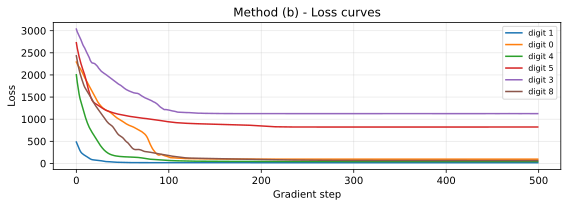

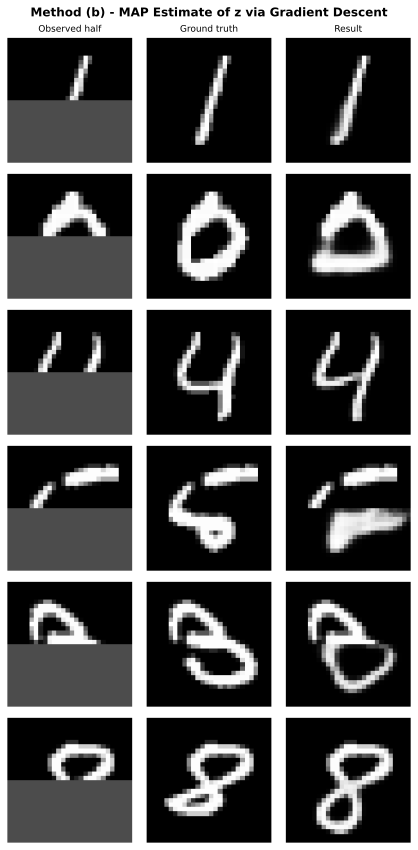

In [ ]:
model.eval()
N_STEPS_B = 500
sigma2 = 0.01
results_b = []
loss_curves_b = []

for i in range(len(test_imgs)):
    x_obs = test_imgs[i:i+1]

    # Start z from the prior
    z = torch.randn(1, model.latent_dim, device=device, requires_grad=True)
    optimizer_b = optim.Adam([z], lr=0.05)
    losses = []

    for _ in range(N_STEPS_B):
        optimizer_b.zero_grad()
        x_hat = model.decode(z)
        # Only compute reconstruction loss on the observed (top) pixels
        rec  = (0.5 / sigma2) * ((x_hat - x_obs) * mask).pow(2).sum()
        # Prior regularisation: keep z close to N(0,I)
        prior = 0.5 * z.pow(2).sum()
        loss = rec + prior
        loss.backward()
        optimizer_b.step()
        losses.append(loss.item())

    loss_curves_b.append(losses)
    with torch.no_grad():
        x_result = model.decode(z)
    results_b.append(mask * x_obs + (1 - mask) * x_result)

# Loss curves
plt.figure(figsize=(8, 3))
for i, lc in enumerate(loss_curves_b):
    plt.plot(lc, label=f'digit {test_labels[i]}')
plt.title('Method (b) - Loss curves')
plt.xlabel('Gradient step')
plt.ylabel('Loss')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_inpainting(
    [observed_display[i] for i in range(len(test_imgs))],
    [test_imgs[i]        for i in range(len(test_imgs))],
    results_b,
    'Method (b) - MAP Estimate of z via Gradient Descent'
)

**Method (c) - Pixel Optimisation via Gradient Descent**

We keep the entire VAE frozen and directly optimise the missing pixel values. We parameterise the free pixels through a sigmoid so they stay in [0,1]:

x_free = sigmoid(y)

Then minimise the negative ELBO of the full image with respect to y. Gradients flow back through the VAE into y using the reparameterisation trick.

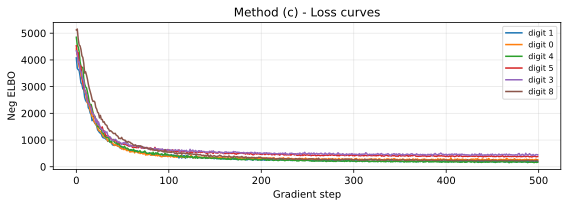

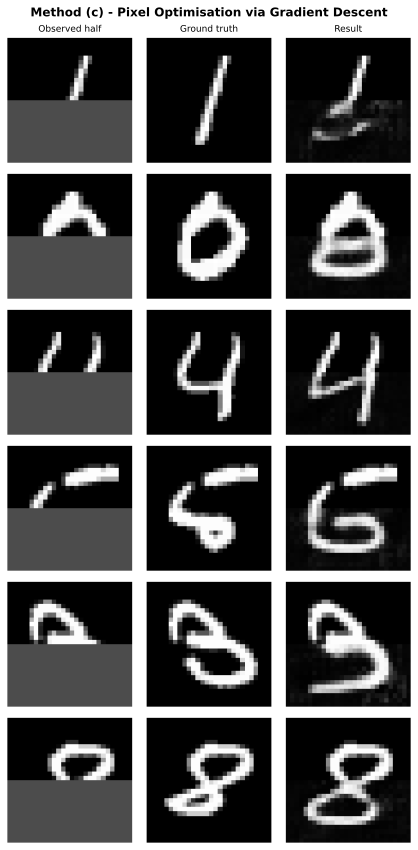

In [ ]:
model.eval()
N_STEPS_C = 500
results_c = []
loss_curves_c = []

for i in range(len(test_imgs)):
    x_obs = test_imgs[i:i+1]

    # Optimise y in unconstrained space, x_free = sigmoid(y) stays in [0,1]
    y = torch.zeros(1, 1, 28, 28, device=device, requires_grad=True)
    optimizer_c = optim.Adam([y], lr=0.05)
    losses = []

    for _ in range(N_STEPS_C):
        optimizer_c.zero_grad()
        x_free = torch.sigmoid(y)
        x_full = mask * x_obs + (1 - mask) * x_free
        # Minimise negative ELBO — gradients flow through VAE back into y
        neg_elbo, _, _ = model.calc_elbo(x_full)
        neg_elbo.backward()
        optimizer_c.step()
        losses.append(neg_elbo.item())

    loss_curves_c.append(losses)
    with torch.no_grad():
        x_free_final = torch.sigmoid(y)
    results_c.append(mask * x_obs + (1 - mask) * x_free_final)

# Loss curves
plt.figure(figsize=(8, 3))
for i, lc in enumerate(loss_curves_c):
    plt.plot(lc, label=f'digit {test_labels[i]}')
plt.title('Method (c) - Loss curves')
plt.xlabel('Gradient step')
plt.ylabel('Neg ELBO')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_inpainting(
    [observed_display[i] for i in range(len(test_imgs))],
    [test_imgs[i]        for i in range(len(test_imgs))],
    results_c,
    'Method (c) - Pixel Optimisation via Gradient Descent'
)

**Comparison of the Three Methods**

**Method (a) - Iterative clamping** works well and is the fastest. The encoder sees the full image at each step, so it uses both the observed pixels and the prior to guide the reconstruction. The result is always a realistic digit because the decoder can only produce things it learned during training. The weakness is that it depends on the random initialisation of the missing pixels.

**Method (b) - Optimising z** also produces good results because we search directly in the latent space, which is smooth and structured. The prior term ||z||² keeps z close to N(0,I) so the decoder always outputs something realistic. The weakness is that gradient descent can get stuck in local minima - the z we find might explain the top half well but not be the most natural completion.

**Method (c) - Optimising pixels** is the most principled method mathematically - we minimise the full negative ELBO which uses both the encoder and decoder. However in practice it is the hardest to optimise because we are working directly in pixel space (784 dimensions) which is much harder than latent space (32 dimensions). Some results look slightly blurry or inconsistent because the optimisation can get stuck.

**Key insight:** methods that are mathematically more correct do not always give better results in practice. Method (a) is the simplest but often produces the cleanest completions because the encoder naturally constrains the solution to the learned data distribution at every step.